# Exploratory Data Analysis

In [1]:
import sys

# Necessary to import from src dir
sys.path.append('..')

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import re
import seaborn as sns

from imblearn.over_sampling import RandomOverSampler
from itertools import combinations
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from src.kmeans import (
    get_contingency_table_for_clustering_results,
    inverse_probability_weighting,
    run_k_means_for_range
)
from src.pca import (
    biplot,
    get_features_by_importance,
    get_PCs_needed_to_explain_variance,
    plot_explained_variance
)
from src.preprocessing import prepare_standardized_datasets

In [3]:
DATA_DIR = r"./data/"
OUTPUT_DIR = r"./outputs/"

TRAIN_DATA = os.path.join(DATA_DIR, "train.csv")
TEST_DATA = os.path.join(DATA_DIR, "test.csv")

df_train = pd.read_csv(TRAIN_DATA)
df_test = pd.read_csv(TEST_DATA)

label_var = "class4"
binary_label_var = "class2"

# Data preprocessing

### Mean dataset: Only mean values, standardized

In [4]:
# Include only the real-valued mean values, but don't exclude anything further than that yet before exploring the data a bit first
cols_to_include = [feat for feat in df_train.columns.to_list() if (feat.endswith(".mean")) or (feat == label_var)]

numeric_vars = cols_to_include[:]
numeric_vars.remove(label_var)

df_train_standardized, df_validation_standardized, df_test_standardized = prepare_standardized_datasets(
    df_train=df_train,
    df_test=df_test,
    data_vars=numeric_vars,
    label_var=label_var,
    label_values=("nonevent", "event"),
    include_validation_split=True,
    validation_split_size=0.2
)

### Full dataset: Mean and std values, standardized

In [5]:
# Full data

cols_to_include_expanded = [feat for feat in df_train.columns.to_list() if (feat.endswith(".mean")) or (feat.endswith(".std")) or (feat == label_var)]
numeric_vars_expanded = cols_to_include_expanded[:]
numeric_vars_expanded.remove(label_var)

df_train_full, df_validation_full, df_test_full = prepare_standardized_datasets(
    df_train=df_train,
    df_test=df_test,
    data_vars=numeric_vars_expanded,
    label_var=label_var,
    label_values=("nonevent", "event"),
    include_validation_split=True,
    validation_split_size=0.2
)

### Reduced dataset: Dropped event type II, standardized

Events of type Ia are ones that have been classified with the highest confidence. Event type II contains events where accuracy of the results is questionable. Event type II could perhaps be dropped initially, to draw clearer distinction between events and nonevents. Let's study the impact of that.

In [6]:
# Drop event type II events

df_train_reduced = df_train_standardized.drop(df_train_standardized[df_train_standardized["class4"] == "II"].index)
df_validation_reduced = df_validation_standardized.drop(df_validation_standardized[df_validation_standardized["class4"] == "II"].index)

### Modified dataset: Combined redundant variables, standardized

Combine variables that have been measured at multiple mast heights.

In [7]:
def combine_columns(
    df_train,
    patterns
):
    for col, pattern in patterns.items():
        cols_to_combine = []
        for feat in df_train.columns.to_list():
            matches = re.findall(pattern, feat)
            if len(matches) > 0:
                cols_to_combine = cols_to_combine + matches
    
        if len(cols_to_combine) > 1:
            df_train[col] = df_train[cols_to_combine].mean(axis=1)
    
            df_train = df_train.drop(columns=cols_to_combine)

    return df_train

In [8]:
patterns = {
    "CO2_combined.mean": rf"CO2\d{{2,3}}.mean",
    "H2O_combined.mean": rf"H2O\d{{2,3}}.mean",
    "NO_combined.mean": rf"NO\d{{2,3}}.mean",
    "NOx_combined.mean": rf"NOx\d{{2,3}}.mean",
    "O3_combined.mean": rf"O3\d{{2,3}}.mean",
    "RHIRGA_combined.mean": rf"RHIRGA\d{{2,3}}.mean",
    "T_combined.mean": rf"T\d{{2,3}}.mean"
}

df_train_combine = combine_columns(df_train, patterns)
df_test_combine = combine_columns(df_test, patterns)

numeric_vars_combo = [feat for feat in df_train_combine.columns.to_list() if (feat.endswith(".mean"))]

df_train_combo, df_validation_combo, df_test_combo = prepare_standardized_datasets(
    df_train=df_train_combine,
    df_test=df_test_combine,
    data_vars=numeric_vars_combo,
    label_var=label_var,
    label_values=("nonevent", "event"),
    include_validation_split=True,
    validation_split_size=0.2
)

## General view at the data

### Correlation matrix: Mean dataset

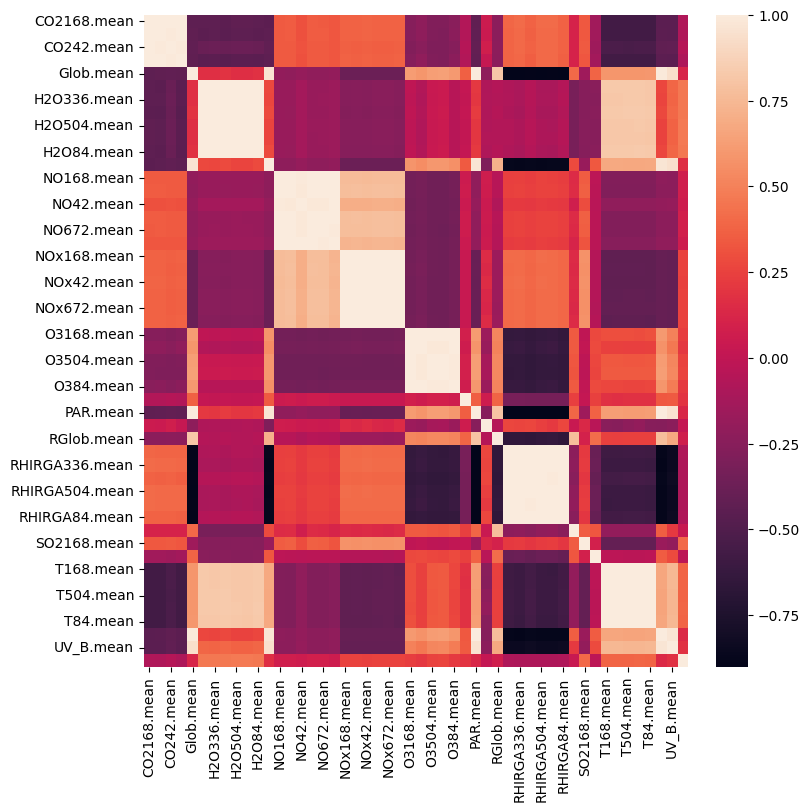

In [9]:
# Correlations between numeric variables

fig, ax = plt.subplots(figsize=(8, 8), layout="constrained")
corr = df_train_standardized.corr(numeric_only=True)
sns.heatmap(corr)
fig.savefig(r"./outputs/correlation_matrix_heatmap_all_mean_vars")
plt.show()

### Correlation matrix: Full dataset

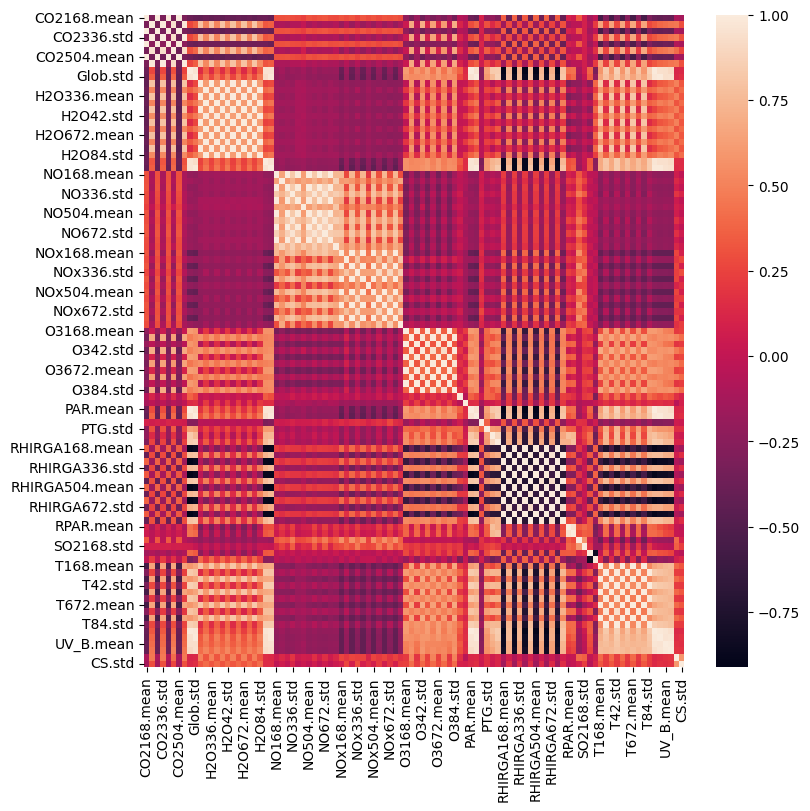

In [10]:
# Correlations for reduced data

fig, ax = plt.subplots(figsize=(8, 8), layout="constrained")
corr = df_train_full.corr(numeric_only=True)
sns.heatmap(corr)
fig.savefig(r"./outputs/correlation_matrix_heatmap_all_data_vars")
plt.show()

### Correlation matrix: Modified dataset

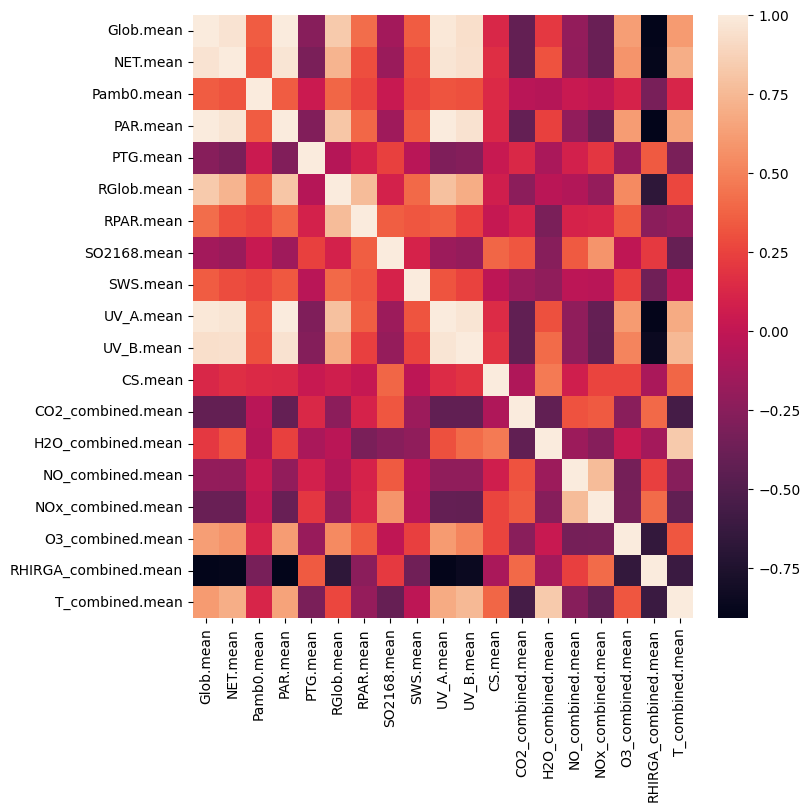

In [11]:
# Correlations for reduced data

fig, ax = plt.subplots(figsize=(8, 8), layout="constrained")
corr = df_train_combo.corr(numeric_only=True)
sns.heatmap(corr)
fig.savefig(r"./outputs/correlation_matrix_heatmap_reduced_mean_vars")
plt.show()

# Pairplot between interesting variables

Done for the modified dataset

In [12]:
# Numeric encoding for classes to be able to visualize better

df_train_combo["class4_numeric"] = 0
df_train_combo.loc[(df_train_combo["class4"] == "Ia"), "class4_numeric"] = 1
df_train_combo.loc[(df_train_combo["class4"] == "Ib"), "class4_numeric"] = 2
df_train_combo.loc[(df_train_combo["class4"] == "II"), "class4_numeric"] = 3

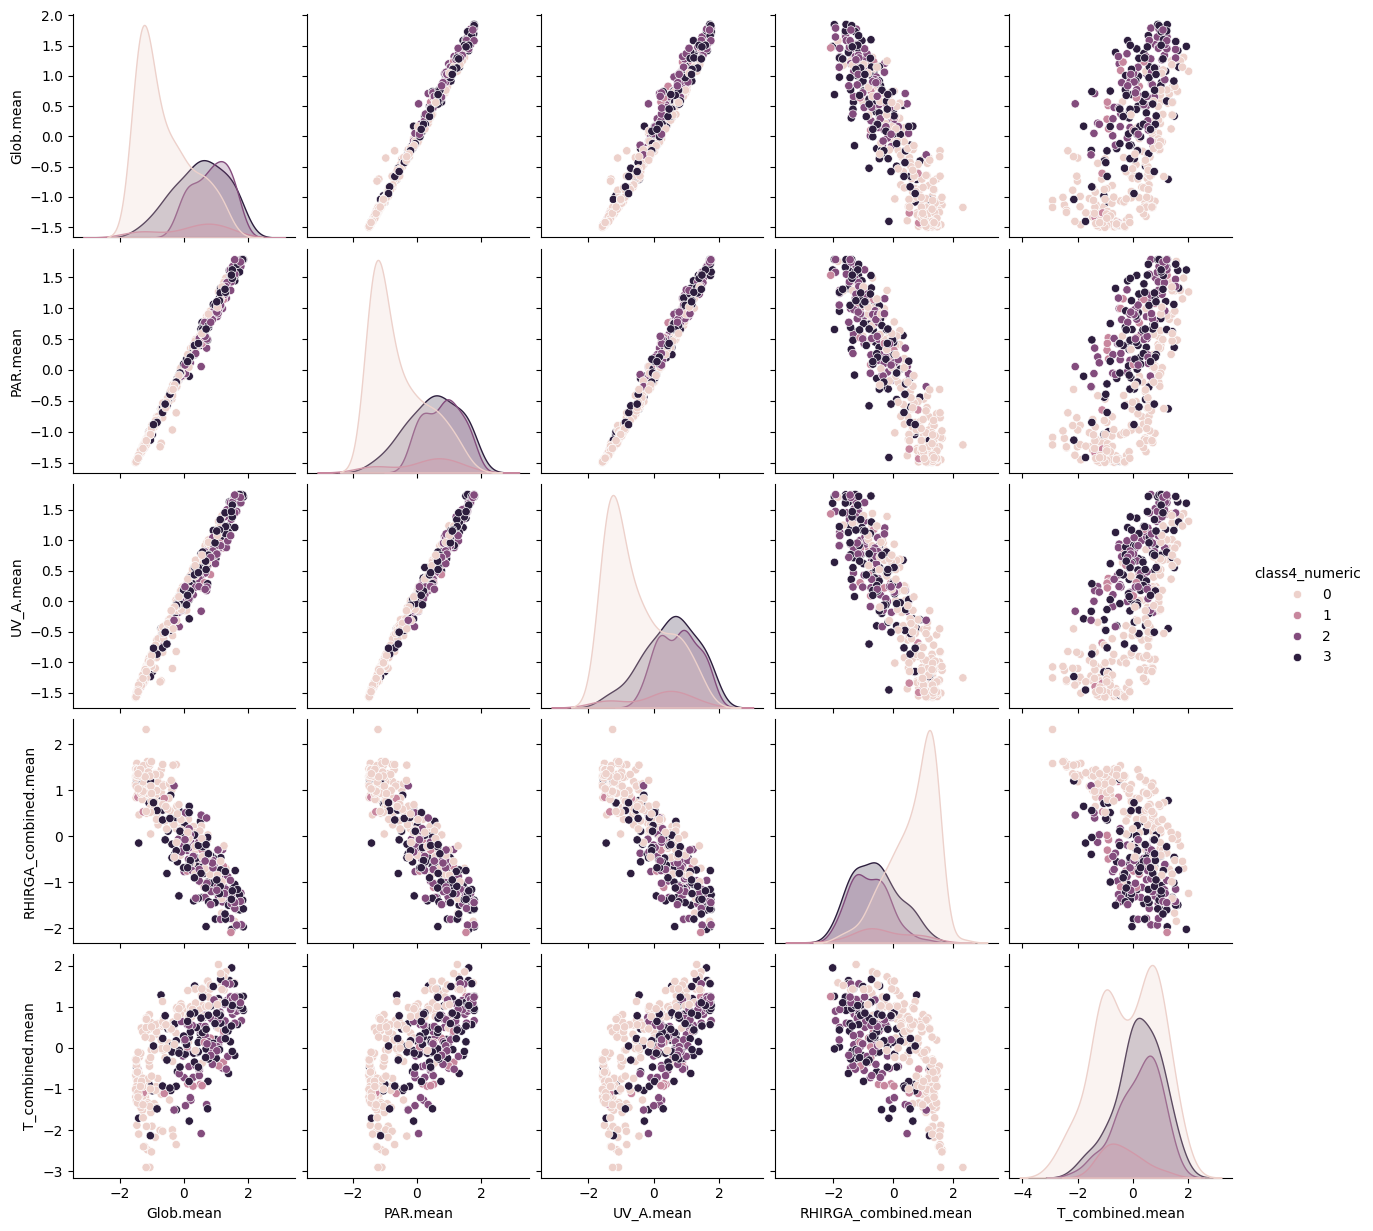

In [13]:
interesting_variables = ['Glob.mean', 'PAR.mean', 'UV_A.mean', 'RHIRGA_combined.mean', 'T_combined.mean']

sns.pairplot(df_train_combo[['Glob.mean', 'PAR.mean', 'UV_A.mean', 'RHIRGA_combined.mean', 'T_combined.mean', 'class4_numeric']], hue='class4_numeric')

## PCA

### PCA: Mean dataset

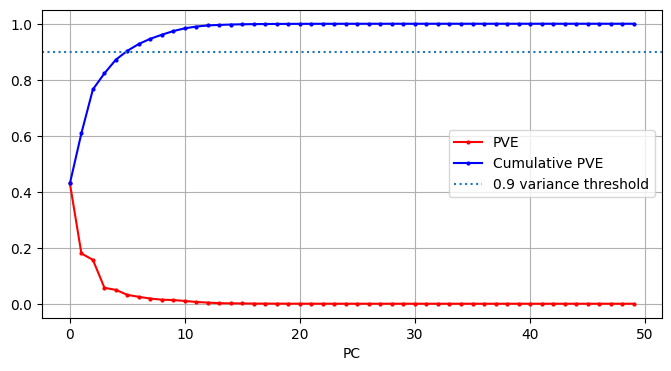

In [14]:
X_train = df_train_standardized[numeric_vars]
y_train = df_train_standardized[[label_var]]

pca = PCA()
pca_results = pca.fit(X_train)
scores = pca.transform(X_train)

fig, ax = plt.subplots(figsize=(8, 4))
plot_explained_variance(pca_results.explained_variance_ratio_, ax)
plt.savefig(r"./outputs/pca_EVR_means_only")

In [15]:
get_PCs_needed_to_explain_variance(pca_results.explained_variance_ratio_, fraction_of_var_explained=0.9)

6

### PC1 & PC2: Mean dataset

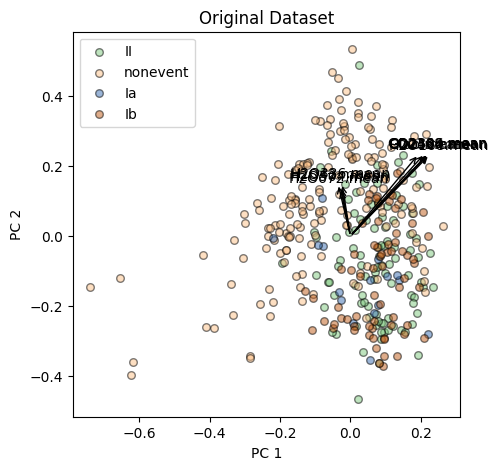

In [16]:
# Plot data projected to PC1 & PC2

fig, ax = plt.subplots(figsize=(5, 5))
top_features = biplot(scores, y_train, ax, title='Original Dataset', pca_result=pca_results, variables=X_train.columns.to_list(), include_arrows=True, n_arrow_variables=10)
plt.savefig(r"./outputs/pca_PC1_PC2_means_only")

In [17]:
# Features that most impact these components
top_features

['H2O672.mean',
 'H2O504.mean',
 'H2O336.mean',
 'H2O168.mean',
 'H2O84.mean',
 'H2O42.mean',
 'RHIRGA42.mean',
 'RHIRGA84.mean',
 'RHIRGA168.mean',
 'RHIRGA336.mean']

In [18]:
# Can also use the function get_features_by_importance()
get_features_by_importance(X_train.columns.to_list(), pca_results, 0, 1, n_features=5)

['H2O672.mean', 'H2O504.mean', 'H2O336.mean', 'H2O168.mean', 'H2O84.mean']

In [19]:
# Look at the significant features for combinations of the first 5 principal components
pc5_combos = list(combinations([1,2,3,4,5], 2))

all_major_features = []

for combo in pc5_combos:
    major_features = get_features_by_importance(X_train.columns.to_list(), pca_results, combo[0], combo[1], n_features=10)
    print(major_features)
    all_major_features = all_major_features + major_features

all_major_features = list(set(all_major_features))

['H2O504.mean', 'H2O672.mean', 'H2O336.mean', 'H2O168.mean', 'H2O84.mean', 'H2O42.mean', 'NO504.mean', 'NO672.mean', 'NO336.mean', 'NO168.mean']
['CS.mean', 'O342.mean', 'O384.mean', 'O3168.mean', 'O3504.mean', 'O3672.mean', 'SO2168.mean', 'H2O672.mean', 'H2O504.mean', 'H2O336.mean']
['CO242.mean', 'CO2504.mean', 'CO2336.mean', 'CO2168.mean', 'H2O672.mean', 'H2O504.mean', 'H2O336.mean', 'H2O168.mean', 'H2O84.mean', 'H2O42.mean']
['Pamb0.mean', 'RPAR.mean', 'RGlob.mean', 'SO2168.mean', 'O342.mean', 'O384.mean', 'PTG.mean', 'H2O672.mean', 'H2O504.mean', 'H2O336.mean']
['CS.mean', 'O3672.mean', 'O3504.mean', 'O342.mean', 'O3168.mean', 'O384.mean', 'NO42.mean', 'SO2168.mean', 'NO84.mean', 'NO672.mean']
['CO242.mean', 'CO2504.mean', 'CO2336.mean', 'CO2168.mean', 'NO42.mean', 'NO504.mean', 'NO672.mean', 'NO336.mean', 'NO168.mean', 'NO84.mean']
['Pamb0.mean', 'RPAR.mean', 'NO42.mean', 'NO84.mean', 'NO168.mean', 'NO672.mean', 'NO504.mean', 'RGlob.mean', 'NO336.mean', 'SO2168.mean']
['CO242.mea

In [20]:
len(all_major_features)

28

In [21]:
# Based on data description and the correlation matrix, could probably also combine (in some manner):
# - Glob.mean, RGlob.mean, perhaps even NET.mean
# - PAR.mean, RPAR.mean
# - UV_A.mean, UV_B.mean

### PCA: Full dataset

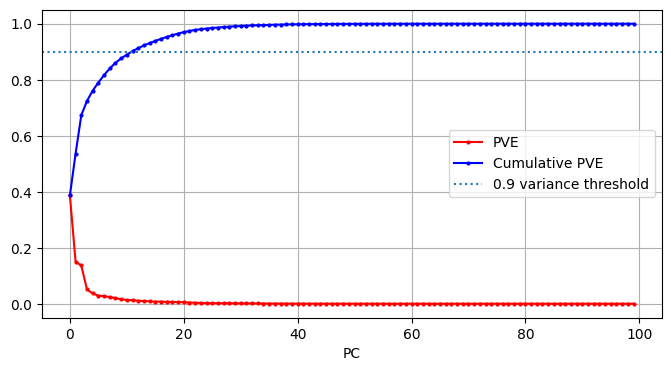

In [22]:
X_train = df_train_full[numeric_vars_expanded]
y_train = df_train_full[[label_var]]

pca = PCA()
pca_results = pca.fit(X_train)
scores = pca.transform(X_train)

fig, ax = plt.subplots(figsize=(8, 4))
plot_explained_variance(pca_results.explained_variance_ratio_, ax)
plt.savefig(r"./outputs/pca_EVR_full_dataset")

### PC1 & PC2: Full dataset

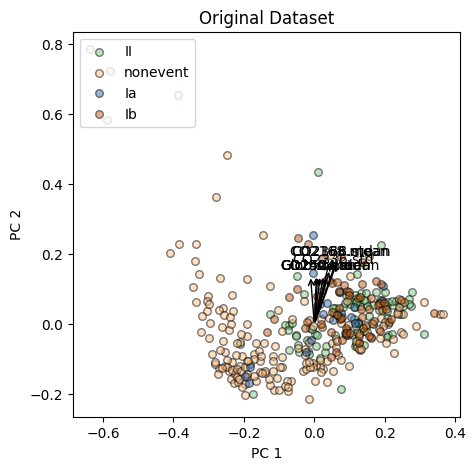

In [23]:
# Plot data projected to PC1 & PC2

fig, ax = plt.subplots(figsize=(5, 5))
top_features = biplot(scores, y_train, ax, title='Original Dataset', pca_result=pca_results, variables=X_train.columns.to_list(), include_arrows=True, n_arrow_variables=10)
plt.savefig(r"./outputs/pca_PC1_PC2_full_dataset")

In [24]:
get_PCs_needed_to_explain_variance(pca_results.explained_variance_ratio_, fraction_of_var_explained=0.9)

12

### PCA: Modified dataset

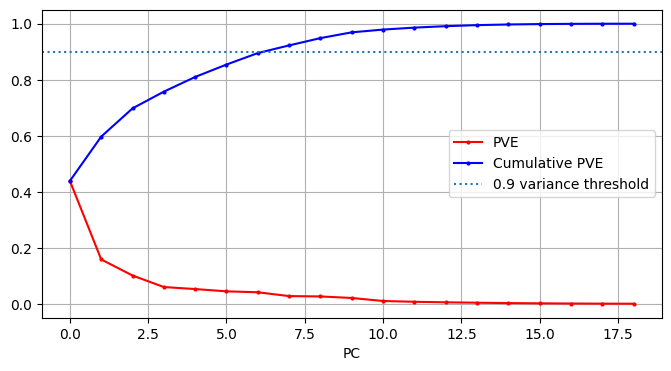

In [25]:
X_train = df_train_combo[numeric_vars_combo]
y_train = df_train_combo[[label_var]]

pca = PCA()
pca_results = pca.fit(X_train)
X_train_pca = pca.transform(X_train)

fig, ax = plt.subplots(figsize=(8, 4))
plot_explained_variance(pca_results.explained_variance_ratio_, ax)
plt.savefig(r"./outputs/pca_EVR_modified_dataset")

In [26]:
get_PCs_needed_to_explain_variance(pca_results.explained_variance_ratio_, fraction_of_var_explained=0.9)

8

### PC1 & PC2: Modified dataset

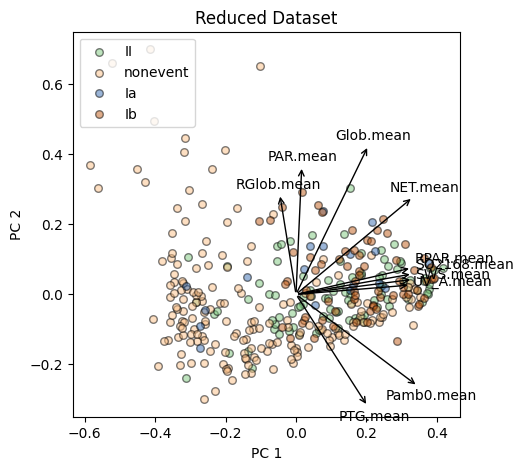

In [27]:
fig, ax = plt.subplots(figsize=(5, 5))
top_features = biplot(X_train_pca, y_train, ax, title='Reduced Dataset', pca_result=pca_results, variables=X_train.columns.to_list(), include_arrows=True, n_arrow_variables=10)
plt.savefig(r"./outputs/PCA_PC1_PC2_modified_dataset")

In [28]:
top_features

['RPAR.mean',
 'RGlob.mean',
 'T_combined.mean',
 'SO2168.mean',
 'H2O_combined.mean',
 'NOx_combined.mean',
 'Glob.mean',
 'PAR.mean',
 'UV_A.mean',
 'NET.mean']

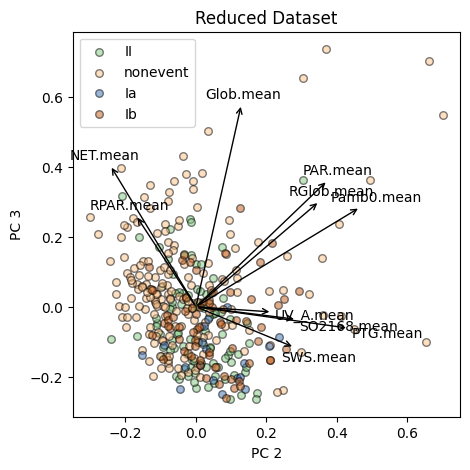

In [29]:
# Check out some other PC combinations

fig, ax = plt.subplots(figsize=(5, 5))
top_features = biplot(X_train_pca, y_train, ax, title='Reduced Dataset', pca_components_by_idx=[1, 2], pca_result=pca_results, variables=X_train.columns.to_list(), include_arrows=True, n_arrow_variables=10)

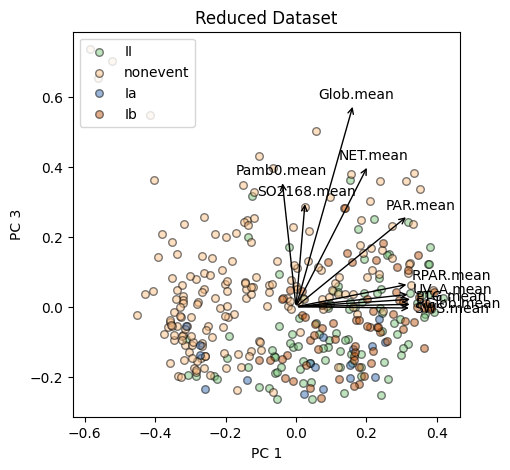

In [30]:
# Check out some other PC combinations

fig, ax = plt.subplots(figsize=(5, 5))
top_features = biplot(X_train_pca, y_train, ax, title='Reduced Dataset', pca_components_by_idx=[0, 2], pca_result=pca_results, variables=X_train.columns.to_list(), include_arrows=True, n_arrow_variables=10)

## K-means

### K-means: Mean dataset

4 clusters,
200 inits,
initialization with k-means++

In [31]:
clustering_results, n_clusters = run_k_means_for_range(
    df_train_standardized,
    numeric_vars,
    n_min=4,
    n_max=4,
    n_init=200,
    init="k-means++"
)

clustering_result = clustering_results[0]
n_clusters = n_clusters[0]

df_train_standardized["cluster"] = clustering_result.labels_

contingency_table = get_contingency_table_for_clustering_results(df_train_standardized["class4"], df_train_standardized["cluster"])

contingency_table

cluster,0,2,3,1
class4,,,,
II,26,0,61,11
Ia,0,0,12,4
Ib,14,0,51,4
nonevent,79,4,13,81


### K-means: Reduced dataset

3 clusters,
200 inits,
initialization with k-means++

In [32]:
# Re-do clustering with 3 clusters

clustering_results, n_clusters = run_k_means_for_range(
    df_train_reduced,
    numeric_vars,
    n_min=3,
    n_max=3,
    n_init=200,
    init="k-means++"
)

clustering_result = clustering_results[0]
n_clusters = n_clusters[0]

df_train_reduced["cluster"] = clustering_result.labels_

contingency_table = get_contingency_table_for_clustering_results(df_train_reduced["class4"], df_train_reduced["cluster"])

contingency_table

cluster,2,0,1
class4,,,
Ia,0,11,5
Ib,0,63,6
nonevent,4,83,90


### K-means: Reduced dataset & weighting

3 clusters,
200 inits,
initialization with k-means++

In [33]:
# Try with weighting

class_weights = inverse_probability_weighting(df_train_reduced["class4"])
weighted_kmeans_result = KMeans(n_clusters=3, init="k-means++", n_init=200, random_state=666, algorithm="lloyd").fit(df_train_reduced[numeric_vars], sample_weight=class_weights)

weighted_contingency_table = get_contingency_table_for_clustering_results(df_train_reduced["class4"], weighted_kmeans_result.labels_)

weighted_contingency_table

col_0,2,0,1
class4,,,
Ia,0,10,6
Ib,0,61,8
nonevent,4,53,120


### K-means: Reduced dataset

2 clusters,
200 inits,
initialization with k-means++

In [34]:
# Clearly K-means cannot separate between classes Ia and Ib, which is understandable, since they're both higher confidence events

# Try with binary classes – note! Classes are nonevents vs. type I events

clustering_results, n_clusters = run_k_means_for_range(
    df_train_reduced,
    numeric_vars,
    n_min=2,
    n_max=2,
    n_init=200,
    init="k-means++"
)

clustering_result = clustering_results[0]
n_clusters = n_clusters[0]

df_train_reduced["cluster"] = clustering_result.labels_

contingency_table = get_contingency_table_for_clustering_results(df_train_reduced["class2"], df_train_reduced["cluster"])

contingency_table

cluster,0,1
class2,,
event,75,10
nonevent,90,87


### K-means: Reduced dataset & weighting

2 clusters,
200 inits,
initialization with k-means++

In [35]:
# Try again with weighting (2 clusters)

class_weights = inverse_probability_weighting(df_train_reduced["class4"])
weighted_kmeans_result = KMeans(n_clusters=2, init="k-means++", n_init=200, random_state=666, algorithm="lloyd").fit(df_train_reduced[numeric_vars], sample_weight=class_weights)

weighted_contingency_table = get_contingency_table_for_clustering_results(df_train_reduced["class2"], weighted_kmeans_result.labels_)

weighted_contingency_table

col_0,1,0
class2,,
event,77,8
nonevent,57,120


Some other kind of weighting scheme, which puts emphasis on classes based on reliability of observations (instead of just proportion, as is done in these simple tests), could work better.

## Try oversampling minority classes

Try to class imbalance problem using Python package imbalanced-learn.

In [36]:
X_train = df_train_standardized[numeric_vars]
y_train = df_train_standardized[[label_var]]

ros = RandomOverSampler(random_state=0)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

In [37]:
X_train_ros.shape

(708, 50)